# Demos: Lecture 9

## Demo 1: Deutsch's algorithm

<img src="fig/deutsch_2.png" width="400px">

In [1]:
import pennylane as qml
import numpy as np

In [12]:
def oracle():
    func = 4
    
    # 1: f(0) = f(1) = 0
    # Do nothing!
    
    # 2: f(0) = f(1) = 1
    if func == 2:
        qml.CNOT(wires=[0, 1])
        qml.PauliX(wires=0)
        qml.CNOT(wires=[0, 1])
        qml.PauliX(wires=0)
        
    # 3: f(0) = 0, f(1) = 1
    if func == 3:
        qml.CNOT(wires=[0, 1])
        
    # 4: f(0) = 1, f(1) = 0
    if func == 4:
        qml.PauliX(wires=0)
        qml.CNOT(wires=[0, 1])
        qml.PauliX(wires=0)

In [13]:
dev = qml.device("default.qubit", wires=2, shots=1)

@qml.qnode(dev)
def deutsch():
    # prepare |-> on second qubit
    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)

    # prepare |+> on first qubit
    qml.Hadamard(wires=0)

    # apply oracle
    oracle()

    # measure in Hadamard basis
    qml.Hadamard(wires=0)
    return qml.sample(wires=0)

In [15]:
deutsch()

array(1)

(<Figure size 800x300 with 1 Axes>, <Axes: >)

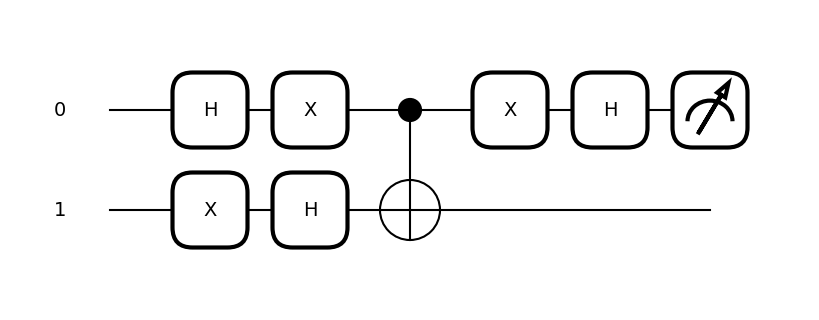

In [16]:
qml.draw_mpl(deutsch)()

## Demo 2: Grover's algorithm

<img src="fig/grover_circuit_full_c.png" width="500px">

In [18]:
n_bits = 5
all_wires = list(range(n_bits + 1))
special_string = [0, 1, 1, 0, 1]

dev = qml.device('default.qubit', wires=all_wires)

In [19]:
def hadamard_transform(wires):
    for wire in wires:
        qml.Hadamard(wires=wire)

def oracle():
    qml.MultiControlledX(wires=all_wires, control_values=special_string)
    
def diffusion():
    hadamard_transform(wires=range(n_bits))
    qml.MultiControlledX(wires=all_wires, control_values=[0]*len(special_string))
    hadamard_transform(wires=range(n_bits))

In [20]:
@qml.qnode(dev)
def grover(num_its):
    # prepare |-> on last qubit
    qml.PauliX(wires=n_bits)
    qml.Hadamard(wires=n_bits)

    # put the top register in uniform superposition
    hadamard_transform(wires=range(n_bits))

    for _ in range(num_its):
        oracle()
        diffusion()
        
    return qml.probs(wires=range(n_bits))

(<Figure size 1300x700 with 1 Axes>, <Axes: >)

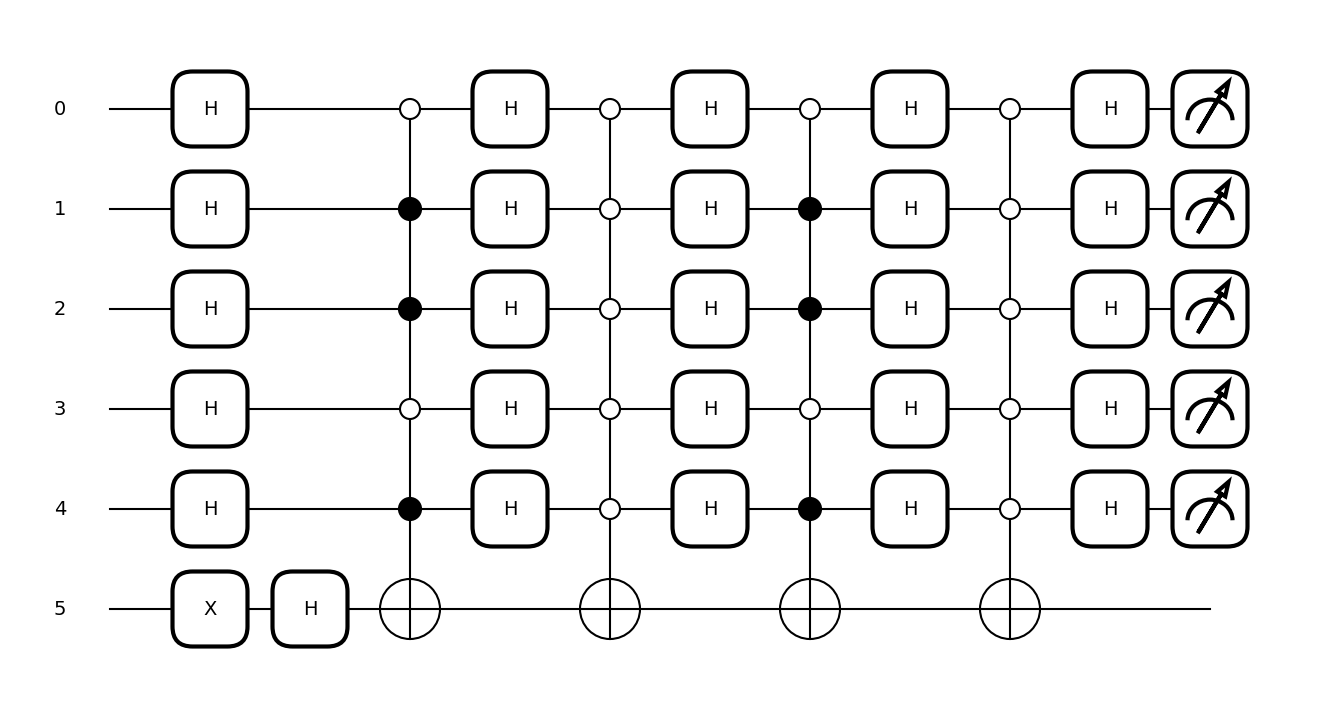

In [21]:
qml.draw_mpl(grover)(2)

For plotting after the implementation

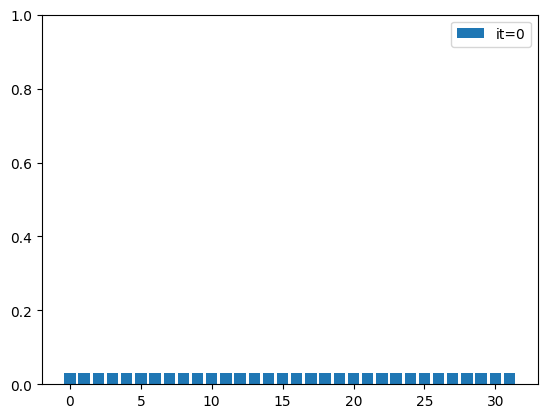

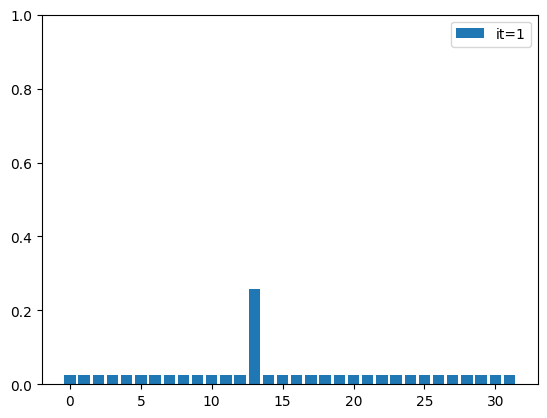

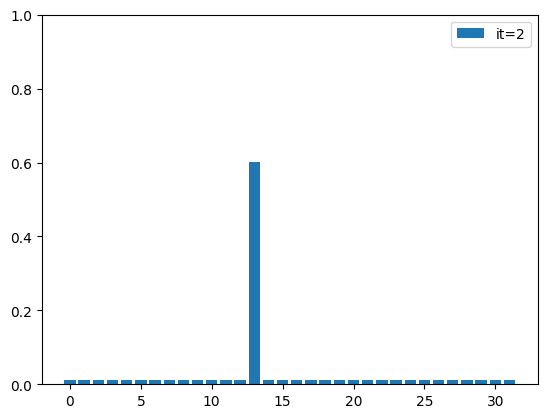

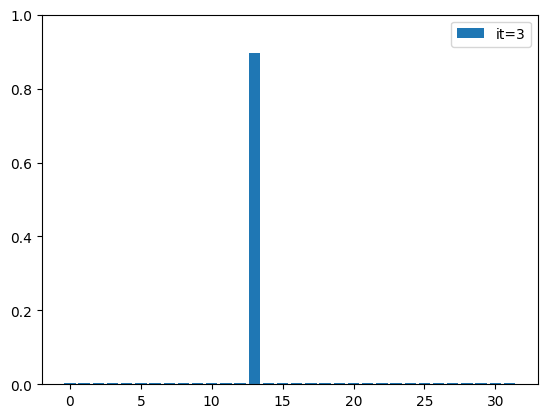

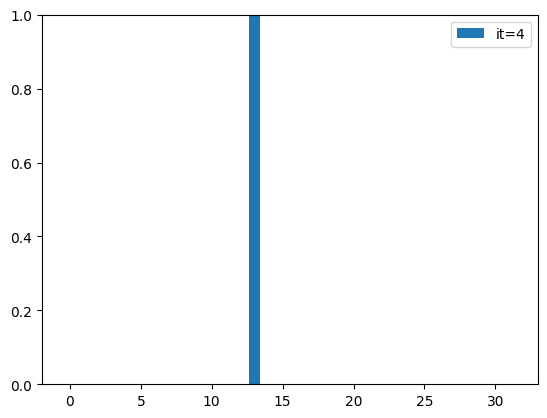

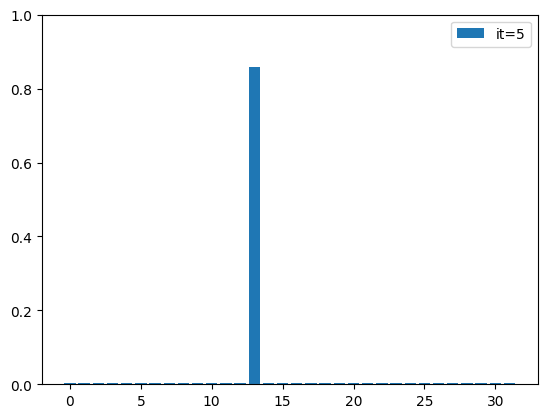

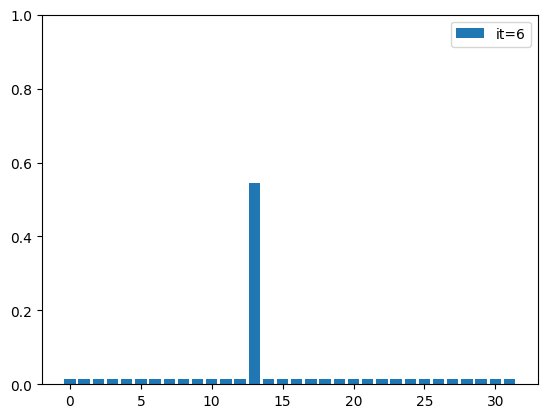

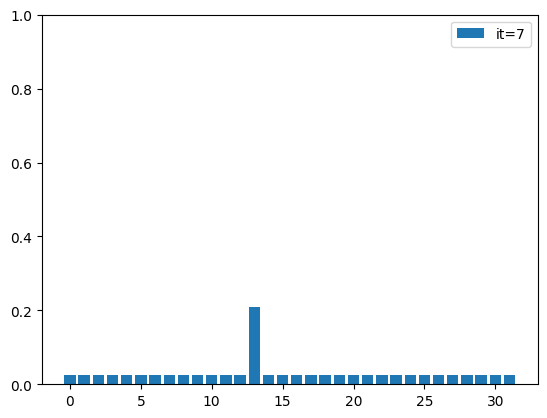

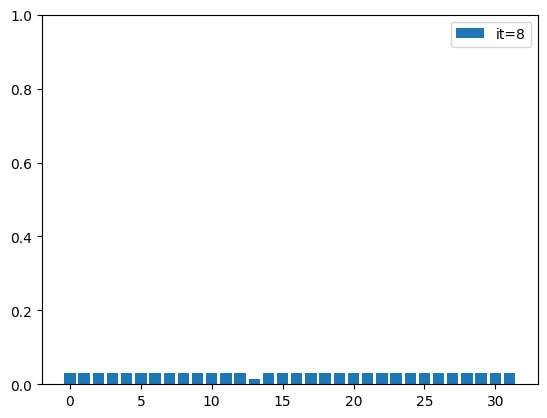

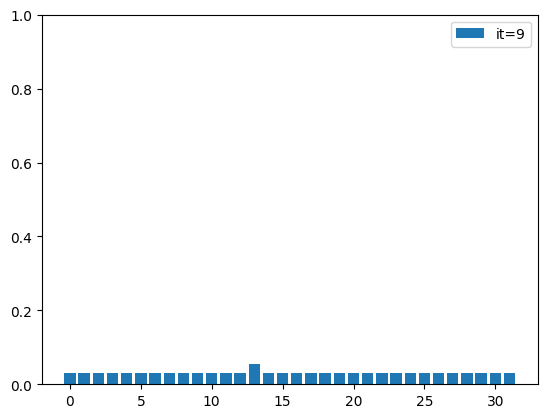

In [22]:
import matplotlib.pyplot as plt

for n in range(10):
    plt.bar(
        list(range(2 ** n_bits)),
        grover(num_its=n),
        label=f"it={n}"
    )
    plt.ylim(0, 1)
    plt.legend()
    plt.show()